In [3]:

!pip install fastf1
!pip install torch
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [4]:
import fastf1
from fastf1 import plotting
from fastf1.core import Laps
import matplotlib.pyplot as plt

from typing import Iterable, List, Optional
import warnings
import pandas as pd
import numpy as np
import requests
import json
from scipy.signal import find_peaks
import io
import os
import math, numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [5]:
# =========================
# CONFIG
# =========================
YEAR                  = 2024
EVENT_NAME            = "Bahrain"
SESSION_FP            = "FP3"                        # "FP1"/"FP2"/"FP3"
SESSION_Q             = "Q"                          # kept for completeness (target lookup)
TELEMETRY_CHANNELS    = ["Speed", "Throttle","Brake","nGear","DRS","RPM"]        # add "Brake","nGear","DRS","RPM" later
CHANNELS              = TELEMETRY_CHANNELS + ["Distance", "Curvature"]
N_SAMPLES             = 2048                         # sequence length (distance-aligned)
CACHE_DIR             = "./f1cache"                  # fastf1 cache

## Getting Circuit Data

In [ ]:
def print_all_races(years=range(2018, 2025)):
    """
    Print all races for each year in `years` using FastF1's event schedule.

    Output format (one per race):
      YEAR | RND | EventName | Country | Location
    """
    for year in years:
        print(f"\n========== {year} ==========")
        try:
            schedule = fastf1.get_event_schedule(year)
        except Exception as e:
            print(f"Could not load schedule for {year}: {e}")
            continue

        # Some FastF1 versions use 'RoundNumber', but be robust:
        round_col_candidates = ["RoundNumber", "EventFormat", "SessionFormat"]
        if "RoundNumber" in schedule.columns:
            round_col = "RoundNumber"
        else:
            # Fallback: just use the index+1 as round
            round_col = None

        for i, row in schedule.iterrows():
            if round_col is not None:
                rnd = int(row.get(round_col, i + 1))
            else:
                rnd = i + 1

            event_name = str(row.get("EventName", "")).strip()
            country    = str(row.get("Country", "")).strip()
            location   = str(row.get("Location", "")).strip()

            print(f"{year} | {rnd:2d} | {event_name} | {country} | {location}")


In [5]:
print_all_races(range(2018, 2025))

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) /root/.cache/fastf1



========== 2018 ==========
2018 |  1 | Australian Grand Prix | Australia | Melbourne
2018 |  2 | Bahrain Grand Prix | Bahrain | Sakhir
2018 |  3 | Chinese Grand Prix | China | Shanghai
2018 |  4 | Azerbaijan Grand Prix | Azerbaijan | Baku
2018 |  5 | Spanish Grand Prix | Spain | Barcelona
2018 |  6 | Monaco Grand Prix | Monaco | Monte Carlo
2018 |  7 | Canadian Grand Prix | Canada | Montréal
2018 |  8 | French Grand Prix | France | Le Castellet
2018 |  9 | Austrian Grand Prix | Austria | Spielberg
2018 | 10 | British Grand Prix | Great Britain | Silverstone
2018 | 11 | German Grand Prix | Germany | Hockenheim
2018 | 12 | Hungarian Grand Prix | Hungary | Budapest
2018 | 13 | Belgian Grand Prix | Belgium | Spa-Francorchamps
2018 | 14 | Italian Grand Prix | Italy | Monza
2018 | 15 | Singapore Grand Prix | Singapore | Singapore
2018 | 16 | Russian Grand Prix | Russia | Sochi
2018 | 17 | Japanese Grand Prix | Japan | Suzuka
2018 | 18 | United States Grand Prix | United States | Austin
2018

In [6]:
"""
Track Mapping for Circuit IDs to FastF1 Event Names

Maps circuit_id values from HOLY_qualifying_v1.csv to:
1. FastF1 event names (for telemetry collection)
2. TUM FTM Raceline URLs (for track geometry)

Note: Some circuits may not have raceline data or FastF1 data available.
"""

# Mapping from circuit_id to FastF1 event name
# FastF1 event names are case-insensitive but we use official capitalization
CIRCUIT_TO_FASTF1 = {
    # Modern F1 circuits (2018+)
    'bahrain': 'Bahrain',
    'sakhir': 'Sakhir',  # Also Bahrain (outer circuit used in 2020)
    'jeddah': 'Jeddah',
    'albert_park': 'Australia',
    'melbourne': 'Australia',
    'imola': 'Emilia Romagna',
    'miami': 'Miami',
    'monaco': 'Monaco',
    'barcelona': 'Spain',
    'catalunya': 'Spain',
    'montreal': 'Canada',
    'montréal': 'Canada',
    'villeneuve': 'Canada',
    'red_bull_ring': 'Austria',
    'spielberg': 'Austria',
    'silverstone': 'Great Britain',
    'hungaroring': 'Hungary',
    'budapest': 'Hungary',
    'spa': 'Belgium',
    'spa_francorchamps': 'Belgium',
    'zandvoort': 'Netherlands',
    'monza': 'Italy',
    'marina_bay': 'Singapore',
    'suzuka': 'Japan',
    'losail': 'Qatar',
    'lusail': 'Qatar',  # Alternative spelling used in dataset
    'austin': 'United States',
    'americas': 'United States',
    'mexico_city': 'Mexico',
    'rodriguez': 'Mexico',
    'interlagos': 'Brazil',
    'são_paulo': 'São Paulo',
    'las_vegas': 'Las Vegas',
    'yas_marina': 'Abu Dhabi',
    'baku': 'Azerbaijan',
    'shanghai': 'China',
    'portimao': 'Portugal',
    'istanbul': 'Turkey',
    'mugello': 'Tuscany',
    'sochi': 'Russia',

    # Historic circuits (limited/no FastF1 data)
    'hockenheimring': 'Germany',
    'nurburgring': 'Nurburgring',
    'ricard': 'France',
    'magny_cours': 'France',
    'sepang': 'Malaysia',
    'yeongam': 'Korea',
    'buddh': 'India',
    'valencia': 'Europe',

    # Very old circuits (pre-2000, likely no FastF1 data)
    'adelaide': None,
    'brands_hatch': None,
    'dallas': None,
    'detroit': None,
    'dijon': None,
    'donington': None,
    'estoril': None,
    'fuji': None,
    'galvez': None,
    'indianapolis': None,
    'jacarepagua': None,
    'jerez': None,
    'kyalami': None,
    'long_beach': None,
    'okayama': None,
    'phoenix': None,
    'zolder': None,
}

# Mapping from circuit_id to  eoJSON URL
# Source: https://github.com/bacinger/f1-circuits
CIRCUIT_TO_RACELINE_URL = {
    # Modern F1 circuits (active)
    'bahrain': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/bh-2002.geojson',
    'sakhir': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/bh-2002.geojson',
    'jeddah': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/sa-2021.geojson',
    'melbourne': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/au-1953.geojson',
    'albert_park': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/au-1953.geojson',
    'baku': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/az-2016.geojson',
    'miami': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-2022.geojson',
    'monaco': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/mc-1929.geojson',
    'barcelona': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/es-1991.geojson',
    'catalunya': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/es-1991.geojson',
    'montreal': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ca-1978.geojson',
    'montréal': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ca-1978.geojson',
    'villeneuve': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ca-1978.geojson',
    'spielberg': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/at-1969.geojson',
    'red_bull_ring': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/at-1969.geojson',
    'silverstone': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/gb-1948.geojson',
    'hungaroring': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/hu-1986.geojson',
    'budapest': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/hu-1986.geojson',
    'spa': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/be-1925.geojson',
    'spa_francorchamps': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/be-1925.geojson',
    'zandvoort': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/nl-1948.geojson',
    'monza': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/it-1922.geojson',
    'marina_bay': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/sg-2008.geojson',
    'suzuka': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/jp-1962.geojson',
    'losail': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/qa-2004.geojson',
    'lusail': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/qa-2004.geojson',
    'austin': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-2012.geojson',
    'americas': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-2012.geojson',
    'mexico_city': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/mx-1962.geojson',
    'rodriguez': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/mx-1962.geojson',
    'interlagos': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/br-1940.geojson',
    'são_paulo': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/br-1940.geojson',
    'las_vegas': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-2023.geojson',
    'yas_marina': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ae-2009.geojson',

    # Recently retired circuits
    'portimao': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/pt-2008.geojson',
    'istanbul': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/tr-2005.geojson',
    'sochi': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ru-2014.geojson',
    'nurburgring': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/de-1927.geojson',
    'hockenheimring': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/de-1932.geojson',
    'sepang': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/my-1999.geojson',
    'shanghai': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/cn-2004.geojson',

    # Historic circuits
    'imola': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/it-1953.geojson',
    'mugello': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/it-1914.geojson',
    'ricard': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/fr-1969.geojson',
    'magny_cours': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/fr-1960.geojson',
    'estoril': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/pt-1972.geojson',
    'jacarepagua': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/br-1977.geojson',
    'kyalami': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/za-1961.geojson',
    'indianapolis': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-1909.geojson',
    'galvez': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ar-1952.geojson',

    # Circuits not in bacinger repository
    'brands_hatch': None,
    'yeongam': None,
    'buddh': None,
    'valencia': None,
    'adelaide': None,
    'dallas': None,
    'detroit': None,
    'dijon': None,
    'donington': None,
    'fuji': None,
    'jerez': None,
    'long_beach': None,
    'okayama': None,
    'phoenix': None,
    'zolder': None,
}


def get_fastf1_event_name(circuit_id: str) -> str:
    """
    Get FastF1 event name for a circuit_id.

    Args:
        circuit_id: Circuit identifier from dataset (e.g., 'monaco', 'bahrain')

    Returns:
        FastF1 event name (e.g., 'Monaco', 'Bahrain') or None if not available
    """
    return CIRCUIT_TO_FASTF1.get(circuit_id.lower())


def get_raceline_url(circuit_id: str) -> str:
    """
    Get bacinger GeoJSON raceline URL for a circuit_id.

    Args:
        circuit_id: Circuit identifier from dataset (e.g., 'monaco', 'bahrain')

    Returns:
        URL to raceline GeoJSON or None if not available
    """
    return CIRCUIT_TO_RACELINE_URL.get(circuit_id.lower())


def has_raceline(circuit_id: str) -> bool:
    """Check if circuit has raceline data available."""
    return get_raceline_url(circuit_id) is not None


def has_fastf1_data(circuit_id: str) -> bool:
    """Check if circuit has FastF1 event mapping."""
    return get_fastf1_event_name(circuit_id) is not None


def get_circuits_with_racelines():
    """Get list of all circuits that have raceline data."""
    return [cid for cid, url in CIRCUIT_TO_RACELINE_URL.items() if url is not None]


def get_circuits_with_fastf1():
    """Get list of all circuits that have FastF1 event mappings."""
    return [cid for cid, name in CIRCUIT_TO_FASTF1.items() if name is not None]


if __name__ == '__main__':
    """Test the mappings"""
    print("=== Track Mapping Test ===\n")

    test_circuits = ['monaco', 'bahrain', 'silverstone', 'adelaide', 'miami']

    for circuit in test_circuits:
        fastf1_name = get_fastf1_event_name(circuit)
        raceline_url = get_raceline_url(circuit)

        print(f"Circuit: {circuit}")
        print(f"  FastF1: {fastf1_name if fastf1_name else 'NOT AVAILABLE'}")
        print(f"  Raceline: {'AVAILABLE' if raceline_url else 'NOT AVAILABLE'}")
        print()

    print(f"\nTotal circuits with racelines: {len(get_circuits_with_racelines())}")
    print(f"Total circuits with FastF1 data: {len(get_circuits_with_fastf1())}")

=== Track Mapping Test ===

Circuit: monaco
  FastF1: Monaco
  Raceline: AVAILABLE

Circuit: bahrain
  FastF1: Bahrain
  Raceline: AVAILABLE

Circuit: silverstone
  FastF1: Great Britain
  Raceline: AVAILABLE

Circuit: adelaide
  FastF1: NOT AVAILABLE
  Raceline: NOT AVAILABLE

Circuit: miami
  FastF1: Miami
  Raceline: AVAILABLE


Total circuits with racelines: 50
Total circuits with FastF1 data: 48


In [7]:
def load_raceline_geojson(raw_url: str) -> pd.DataFrame:
    """
    Load raceline GeoJSON and return float columns x_m, y_m.
    Extracts coordinates from GeoJSON LineString geometry.
    """
    r = requests.get(raw_url, timeout=30)
    r.raise_for_status()

    geojson_data = json.loads(r.text)

    # Extract coordinates from GeoJSON structure
    # GeoJSON can be FeatureCollection or single Feature
    if geojson_data.get('type') == 'FeatureCollection':
        features = geojson_data.get('features', [])
        if not features:
            raise ValueError("No features found in GeoJSON")
        # Take first feature (usually the track)
        geometry = features[0].get('geometry', {})
    elif geojson_data.get('type') == 'Feature':
        geometry = geojson_data.get('geometry', {})
    else:
        # Might be just geometry
        geometry = geojson_data

    # Extract coordinates from LineString or MultiLineString
    coords = []
    if geometry.get('type') == 'LineString':
        coords = geometry.get('coordinates', [])
    elif geometry.get('type') == 'MultiLineString':
        # Flatten all line segments
        for line in geometry.get('coordinates', []):
            coords.extend(line)
    else:
        raise ValueError(f"Unsupported geometry type: {geometry.get('type')}")

    if not coords:
        raise ValueError("No coordinates found in GeoJSON")

    # Convert to DataFrame
    # GeoJSON coordinates are [lon, lat]
    df = pd.DataFrame(coords, columns=['lon', 'lat'])

    # If coordinates look like lat/lon (small values), convert to meters using Web Mercator-like projection
    # This is a heuristic: if values are between -180 and 180, assume lat/lon
    if df['lon'].abs().max() < 200 and df['lat'].abs().max() < 200:
        # Use a local tangent plane projection centered on the track
        # This is more accurate than simple degree multiplication
        center_lon = df['lon'].mean()
        center_lat = df['lat'].mean()

        # Convert to radians
        lon_rad = np.radians(df['lon'].values)
        lat_rad = np.radians(df['lat'].values)
        center_lon_rad = np.radians(center_lon)
        center_lat_rad = np.radians(center_lat)

        # Earth radius in meters
        R = 6371000

        # Project to local Cartesian coordinates (meters)
        # x = R * cos(center_lat) * (lon - center_lon)
        # y = R * (lat - center_lat)
        df['x_m'] = R * np.cos(center_lat_rad) * (lon_rad - center_lon_rad)
        df['y_m'] = R * (lat_rad - center_lat_rad)
    else:
        # Already in meters or other Cartesian system
        df['x_m'] = df['lon']
        df['y_m'] = df['lat']

    # Keep only x_m and y_m columns
    df = df[['x_m', 'y_m']].copy()
    df = df.dropna(subset=["x_m", "y_m"]).reset_index(drop=True)

    if (df.iloc[0] != df.iloc[-1]).any():
        df = pd.concat([df, df.iloc[[0]]], ignore_index=True)

    return df

def arc_length(df: pd.DataFrame) -> pd.Series:
    dx = np.diff(df.x_m, prepend=df.x_m.iloc[0])
    dy = np.diff(df.y_m, prepend=df.y_m.iloc[0])
    return pd.Series(np.cumsum(np.hypot(dx, dy)), name="s_m")

def curvature_from_xy(x: np.ndarray, y: np.ndarray, s: np.ndarray) -> np.ndarray:
    # central differences on arc-length parameter s
    # guard against non-strictly-increasing s
    s = np.maximum.accumulate(s + 1e-12*np.arange(len(s)))
    x_s  = np.gradient(x, s)
    y_s  = np.gradient(y, s)
    x_ss = np.gradient(x_s, s)
    y_ss = np.gradient(y_s, s)
    kappa = np.abs(x_s * y_ss - y_s * x_ss) / np.power(x_s**2 + y_s**2, 1.5)
    # numerical safety
    kappa = np.nan_to_num(kappa, nan=0.0, posinf=0.0, neginf=0.0)
    return kappa

def resample_equal_arclength(df: pd.DataFrame, step_m: float = 2.0) -> pd.DataFrame:
    """Resample polyline to ~constant spacing along s, improving curvature stability."""
    s = arc_length(df).values
    s_new = np.arange(0, s[-1], step_m)
    # linear interpolation
    x_new = np.interp(s_new, s, df.x_m.values)
    y_new = np.interp(s_new, s, df.y_m.values)
    out = pd.DataFrame({"s_m": s_new, "x_m": x_new, "y_m": y_new})
    # close loop exactly
    if (out.iloc[0][["x_m","y_m"]].values != out.iloc[-1][["x_m","y_m"]].values).any():
        out = pd.concat([out, out.iloc[[0]]], ignore_index=True)
        out.loc[out.index[-1], "s_m"] = out["s_m"].iloc[-2] + step_m
    return out

def load_track_raceline(circuit_id: str, step_m: float = 2.0):
    """
    Full pipeline:
    1. Look up track URL from CIRCUIT_TO_RACELINE_URL
    2. Load GeoJSON raceline
    3. Resample to equal arc length
    4. Compute curvature
    5. Return raceline df + start point
    """
    url = get_raceline_url(circuit_id)
    if url is None:
        raise ValueError(f"No raceline available for circuit '{circuit_id}'")

    # Load xy from GeoJSON
    df = load_raceline_geojson(url)

    # Resample (constant spacing)
    rl_eq = resample_equal_arclength(df, step_m=step_m)

    # Curvature
    kappa = curvature_from_xy(
        rl_eq.x_m.values,
        rl_eq.y_m.values,
        rl_eq.s_m.values
    )
    rl_eq["kappa"] = kappa

    # Start point = s_m == 0 row
    start_point = rl_eq.iloc[0]

    return rl_eq, start_point

Start-of-polyline point (s_m = 0):
s_m      0.000000
x_m   -357.714119
y_m    -50.592509
Name: 0, dtype: float64
         s_m         x_m        y_m         kappa
0        0.0 -357.714119 -50.592509  7.277147e-15
1        2.0 -357.658408 -48.593285  3.626203e-15
2        4.0 -357.602696 -46.594061  0.000000e+00
3        6.0 -357.546985 -44.594837  1.237042e-17
4        8.0 -357.491274 -42.595613  3.576076e-15
...      ...         ...        ...           ...
2706  5412.0 -358.150377 -57.007851  9.038853e-17
2707  5414.0 -358.014686 -55.012459  4.097613e-15
2708  5416.0 -357.878995 -53.017068  1.035630e-15
2709  5418.0 -357.743304 -51.021676  2.198521e-14
2710  5420.0 -357.714119 -50.592509  3.818817e-13

[2711 rows x 4 columns]
=== Start Point ===
s_m      0.000000
x_m   -357.714119
y_m    -50.592509
Name: 0, dtype: float64

=== Raceline (first 10 rows, no x/y) ===
    s_m         kappa
0   0.0  7.277147e-15
1   2.0  3.626203e-15
2   4.0  0.000000e+00
3   6.0  1.237042e-17
4   8.0  3.5

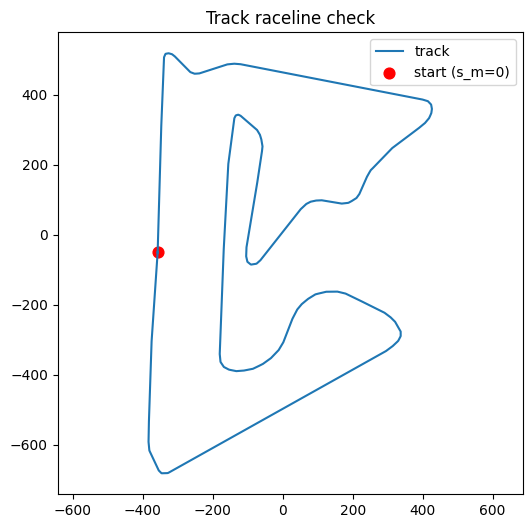

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- build raceline from GEOJSON instead of CSV ---
RAW_URL = 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/bh-2002.geojson'

raceline = load_raceline_geojson(RAW_URL)   # uses your function (x_m, y_m)
rl_eq = resample_equal_arclength(raceline, 2.0)

# compute curvature (optional, but you already do this)
kappa = curvature_from_xy(rl_eq.x_m.values, rl_eq.y_m.values, rl_eq.s_m.values)
rl_eq["kappa"] = kappa

# --- point where s_m = 0 (start of polyline) ---
start_point = rl_eq.iloc[0]  # this row has s_m == 0
print("Start-of-polyline point (s_m = 0):")
print(start_point[["s_m", "x_m", "y_m"]])

print(rl_eq)

def print_without_xy(df: pd.DataFrame):
    cols = [c for c in df.columns if c not in ("x_m", "y_m")]
    print(df[cols])

# --- TEST 1: Load a raceline and print start point ---
rl_eq, start = load_track_raceline("bahrain")

print("=== Start Point ===")
print(start[["s_m", "x_m", "y_m"]])
print()

# --- TEST 2: Check first 10 rows WITHOUT x_m and y_m ---
print("=== Raceline (first 10 rows, no x/y) ===")
print_without_xy(rl_eq.head(10))
print()

# --- TEST 3: Sanity check for curvature values ---
print("=== Curvature stats ===")
print(rl_eq["kappa"].describe())
print()

# --- TEST 4: Plot (optional but recommended) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(rl_eq.x_m, rl_eq.y_m, label="track")
plt.scatter(start.x_m, start.y_m, color="red", s=60, label="start (s_m=0)")
plt.axis("equal")
plt.title("Track raceline check")
plt.legend()
plt.show()



In [9]:
def build_fastf1_to_rl_eq(step_m: float = 2.0) -> dict[str, pd.DataFrame]:
    """
    Build a dict mapping FastF1 event names -> rl_eq DataFrames.

    For each circuit_id that:
      1) has a bacinger GeoJSON raceline URL, and
      2) has a FastF1 event mapping,

    we load the raceline, resample it, compute curvature, and store the
    resulting rl_eq DataFrame under the FastF1 event name key.

    If multiple circuit_ids map to the same FastF1 event name
    (e.g. 'melbourne' and 'albert_park' -> 'Australia'), the first one
    encountered wins and later ones are skipped.
    """
    fastf1_to_rl = {}

    for circuit_id, url in CIRCUIT_TO_RACELINE_URL.items():
        if url is None:
            continue  # no raceline for this circuit

        event_name = get_fastf1_event_name(circuit_id)
        if event_name is None:
            # raceline exists but we don't have a FastF1 mapping (historic, etc.)
            continue

        # Avoid reloading the same track if multiple circuit_ids map to
        # the same FastF1 event (e.g., 'melbourne'/'albert_park' -> 'Australia')
        if event_name in fastf1_to_rl:
            continue

        rl_eq, _ = load_track_raceline(circuit_id, step_m=step_m)
        fastf1_to_rl[event_name] = rl_eq

    return fastf1_to_rl

In [10]:
fastf1_tracks = build_fastf1_to_rl_eq(step_m=2.0)

print(fastf1_tracks.keys())   # e.g. dict_keys(['Bahrain', 'Monaco', 'Spain', ...])

bahrain_rl = fastf1_tracks["Bahrain"]
print(bahrain_rl.head())

dict_keys(['Bahrain', 'Sakhir', 'Jeddah', 'Australia', 'Azerbaijan', 'Miami', 'Monaco', 'Spain', 'Canada', 'Austria', 'Great Britain', 'Hungary', 'Belgium', 'Netherlands', 'Italy', 'Singapore', 'Japan', 'Qatar', 'United States', 'Mexico', 'Brazil', 'São Paulo', 'Las Vegas', 'Abu Dhabi', 'Portugal', 'Turkey', 'Russia', 'Nurburgring', 'Germany', 'Malaysia', 'China', 'Emilia Romagna', 'Tuscany', 'France'])
   s_m         x_m        y_m         kappa
0  0.0 -357.714119 -50.592509  7.277147e-15
1  2.0 -357.658408 -48.593285  3.626203e-15
2  4.0 -357.602696 -46.594061  0.000000e+00
3  6.0 -357.546985 -44.594837  1.237042e-17
4  8.0 -357.491274 -42.595613  3.576076e-15


## Prep for Transformer Input

In [11]:
def pick_best_soft_fp_lap(laps: pd.DataFrame, driver: str) -> pd.Series | None:
    """Fastest FP soft-tyre lap (non in/out) for a driver, or None."""
    cand = (laps.pick_drivers(driver)
                 .pick_tyre('SOFT')
                 .pick_quicklaps()
                 .sort_values('LapTime'))
    return cand.iloc[0] if len(cand) else None

def get_driver_telemetry(fp_session, driver: str, channels: list[str]) -> pd.DataFrame | None:
    """
    Return raw lap telemetry (Distance plus requested channels) for driver's best FP Soft lap.
    Columns will include: 'Distance' + the subset of channels that exist.
    """
    lap = pick_best_soft_fp_lap(fp_session.laps, driver)
    if lap is None:
        return None
    tel = lap.get_telemetry()  # FastF1 DataFrame
    if "Distance" not in tel.columns:
        return None
    tel = tel.dropna(subset=["Distance"]).sort_values("Distance")
    keep = ["Distance"] + [c for c in channels if c in tel.columns and c != "Distance"]
    return tel[keep].reset_index(drop=True)

def resample_by_distance(df: pd.DataFrame, N: int) -> pd.DataFrame:
    """
    Resample selected channels to a fixed grid over Distance in [0, max), N points.
    Assumes df has 'Distance' and numeric columns for the rest.
    """
    d = df["Distance"].to_numpy(dtype=float)
    L = float(np.nanmax(d))
    grid = np.linspace(0.0, L, N, endpoint=False)
    out = {"Distance": grid}
    for col in df.columns:
        if col == "Distance":
            continue
        out[col] = np.interp(grid, d, df[col].to_numpy(dtype=float))
    return pd.DataFrame(out)

def track_features_on_distance_grid(rl_eq: pd.DataFrame, dist_grid: np.ndarray) -> dict[str, np.ndarray]:
    """
    Given rl_eq with columns 's_m', 'kappa' (and optionally 'altitude_m'),
    and a Distance grid (0..L) for a lap, return per-sample track features
    interpolated onto that grid.

    Returns dict mapping feature name -> np.ndarray of shape (N,)
    """
    s = rl_eq["s_m"].to_numpy(dtype=float)
    s_norm = s / s[-1]

    # normalize the lap distance grid to [0,1] so we don't care about absolute scaling
    d_norm = dist_grid / dist_grid.max()

    out: dict[str, np.ndarray] = {}

    # curvature
    if "kappa" not in rl_eq.columns:
        raise ValueError("rl_eq must contain a 'kappa' column (curvature).")
    kappa = rl_eq["kappa"].to_numpy(dtype=float)
    out["Curvature"] = np.interp(d_norm, s_norm, kappa).astype(np.float32)

    return out


In [29]:
def build_weekend_sequences(
    year: int,
    event_name: str,
    fastf1_tracks: dict[str, pd.DataFrame],
    channels=CHANNELS,
    N=N_SAMPLES,
):
    """
    Build one (C,N) sequence per driver from FP (best Soft lap) for a given event.

    Uses:
      - `fastf1_tracks`: dict mapping FastF1 event_name -> rl_eq DataFrame
        (with columns s_m, x_m, y_m, kappa, and optional altitude_m)
      - per-driver FastF1 telemetry from the FP session

    Adds:
      - Track-level channels (Curvature, optional Altitude) that are consistent
        across drivers for this circuit, interpolated onto each driver's
        Distance grid.

    Args:
        year:        Race year, e.g. 2024
        event_name:  FastF1 event name, e.g. "Bahrain", "Monaco"
        fastf1_tracks: dict[str, pd.DataFrame], from build_fastf1_to_rl_eq(...)
        channels:    list of telemetry channels, e.g. ["Speed", "Throttle"]
        N:           sequence length (number of distance samples)

    Returns:
        seqs: dict[driver_code -> (C, N) float32 array], z-scored per channel globally
        meta: list of dicts with keys:
              - "driver": driver code (e.g. "VER")
              - "year": year
              - "event_name": event_name
              - "distance_max": raw lap distance (meters)
              - "channels": list of channel names (including Curvature, Altitude, etc.)
        raw_tables: dict[driver_code -> raw telemetry DataFrame] before resample
    """
    print("\n==============================")
    print("DEBUG: Starting weekend build")
    print(f"Requested weekend: year={year}, event_name={event_name}")
    print(f"Available FastF1 track keys: {list(fastf1_tracks.keys())[:8]} ...")
    print("==============================\n")

    # --- resolve rl_eq for this event using the mapping dictionary ---
    if event_name not in fastf1_tracks:
        raise KeyError(
            f"No rl_eq raceline found for event_name '{event_name}'. "
            "Check your fastf1_tracks mapping or build_fastf1_to_rl_eq."
        )
    rl_eq = fastf1_tracks[event_name]

    # --- load FP session and list of drivers ---
    print("LOADING SESSION" + str(year) + " || " + str(event_name))
    fp = fastf1.get_session(year, event_name, SESSION_FP)
    fp.load()
    print(" DONE LOADING ======================")
    drivers = sorted(fp.laps["Driver"].unique())

    per_driver: dict[str, dict] = {}
    raw_tables: dict[str, pd.DataFrame] = {}
    distance_max: dict[str, float] = {}

    print( "1 +++++++++++++++++++++++++++++++++++++++++")
    for drv in drivers:
        # per-driver best Soft FP lap telemetry
        df = get_driver_telemetry(fp, drv, channels)
        if df is None or df.empty:
            continue

        raw_tables[drv] = df

        # resample telemetry to fixed Distance grid of length N
        df_rs = resample_by_distance(df, N)   # columns: "Distance" + telemetry channels
        dist_grid = df_rs["Distance"].to_numpy(dtype=float)

        # --- track-level features on this driver's distance grid ---
        track_feats = track_features_on_distance_grid(rl_eq, dist_grid)
        # add them as columns to df_rs
        for name, arr in track_feats.items():
            df_rs[name] = arr

        # Telemetry channels (Speed, Throttle, ...) +
        # track-level channels (Curvature, maybe Altitude)
        extra_track_channels = list(track_feats.keys())   # e.g. ["Curvature", "Altitude"]
        model_channels = channels + extra_track_channels

        # Stack to (C,N) arrays:
        # - with_dist includes Distance as first row (for inspection / plotting)
        # - C_only is only the channels the model will see
        with_dist = np.stack(
            [df_rs[c].to_numpy(dtype=np.float32) for c in (["Distance"] + model_channels)],
            axis=0
        )

        C_only = np.stack(
            [df_rs[c].to_numpy(dtype=np.float32) for c in model_channels],
            axis=0
        )

        per_driver[drv] = {
            "C_only": C_only,
            "with_dist": with_dist,
            "model_channels": model_channels,
        }
        distance_max[drv] = float(df["Distance"].max())
    print( "2 +++++++++++++++++++++++++++++++++++++++++")
    if not per_driver:
        raise RuntimeError("No sequences built—check FP session/tyre/driver availability.")

    # --- z-score per channel across drivers (on C_only for model inputs) ---
    arrays = [per_driver[d]["C_only"] for d in per_driver]
    C = arrays[0].shape[0]
    # concatenate along time dimension: (C, N * num_drivers)
    cat = np.concatenate([x.reshape(C, -1) for x in arrays], axis=1)

    mean = cat.mean(axis=1, keepdims=True)
    std  = cat.std(axis=1, keepdims=True) + 1e-8

    seqs: dict[str, np.ndarray] = {
        d: (per_driver[d]["C_only"] - mean) / std
        for d in per_driver
    }
    print( "3 +++++++++++++++++++++++++++++++++++++++++")
    meta = [{
        "driver": d,
        "year": year,
        "event_name": event_name,
        "distance_max": distance_max[d],
        "channels": per_driver[d]["model_channels"],   # useful for debugging
    } for d in per_driver]

    return seqs, meta, raw_tables

In [13]:
# =========================
# TARGETS & DATASET FOR TRAINING
# =========================
from torch.utils.data import DataLoader

def get_driver_q_best_time(q_session, driver: str) -> float | None:
    """Best qualifying lap time (seconds) across Q1/Q2/Q3 for a driver."""
    laps = q_session.laps.pick_drivers(driver).pick_quicklaps()
    if len(laps) == 0:
        return None
    best = laps["LapTime"].min()
    return float(best.total_seconds())

class LapDataset(Dataset):
    """Stores (C,N) tensors and scalar targets."""
    def __init__(self, X_dict: dict[str, np.ndarray], y_dict: dict[str, float], drivers: list[str]):
        xs, ys = [], []
        for d in drivers:
            if d in X_dict and d in y_dict:
                xs.append(torch.from_numpy(X_dict[d]))   # (C,N)
                ys.append(torch.tensor(y_dict[d], dtype=torch.float32))
        if not xs:
            raise RuntimeError("No overlapping drivers with both X and y.")
        self.X = torch.stack(xs, dim=0)   # (B,C,N)
        self.y = torch.stack(ys, dim=0)   # (B,)
        self.drivers = drivers
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

def build_weekend_dataset_with_targets(
    year: int,
    event_name: str,
    fastf1_tracks: dict[str, pd.DataFrame],
    channels=CHANNELS,
    N=N_SAMPLES,
):
    """
    Build inputs (X_dict) and targets (y_dict) for a single weekend.

    Returns:
      X_dict: dict[driver_code -> (C,N) float32 array]
      y_dict: dict[driver_code -> float target]  (e.g. best Q lap time)
      drivers: list of driver codes present in this weekend
    """
    # --- FP sequences (inputs): now pass fastf1_tracks ---
    print("BUILD WEEKEND DATASETS" + str(year) + " || " + str(event_name))
    X_dict, meta, _raw = build_weekend_sequences(
        year=year,
        event_name=event_name,
        fastf1_tracks=fastf1_tracks,
        channels=channels,
        N=N,
    )

    # Qualifying targets
    q = fastf1.get_session(year, event_name, SESSION_Q); q.load()
    y_dict = {}
    for d in X_dict.keys():
        y = get_driver_q_best_time(q, d)
        if y is not None:
            y_dict[d] = y

    drivers_common = sorted(set(X_dict.keys()) & set(y_dict.keys()))
    if not drivers_common:
        raise RuntimeError("No common drivers with FP sequences and Q targets.")
    return X_dict, y_dict, drivers_common



In [14]:
# =========================
# TRANSFORMER ENCODER (no training here; this is the exact model you'd use)
# =========================
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=8192):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)
    def forward(self, x):  # x: (B,N,d)
        return x + self.pe[:x.size(1)]

class LapTransformer(nn.Module):
    """
    Sequence → scalar head (e.g., predicted Q lap time).
    Not trained here; included to show the exact expected (B,C,N) input.
    """
    def __init__(self, in_ch=2, d_model=128, nhead=4, depth=4, d_ff=256, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Conv1d(in_ch, d_model, kernel_size=1)  # (B,C,N)->(B,d,N)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=d_ff,
                                               dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.pos = SinusoidalPE(d_model)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model*2),
            nn.Linear(d_model*2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x):  # x: (B,C,N) z-scored channels over distance
        z = self.input_proj(x).transpose(1, 2)   # (B,N,d)
        z = self.pos(z)
        z = self.encoder(z)                      # (B,N,d)
        pooled = torch.cat([z.mean(1), z.amax(1)], dim=-1)  # (B,2d)
        y = self.head(pooled).squeeze(-1)        # (B,)
        return y

In [15]:
CACHE_DIR = "/content/f1cache"         # or any folder path you like
os.makedirs(CACHE_DIR, exist_ok=True)  # <- create directory if it doesn't exist

fastf1.Cache.enable_cache(CACHE_DIR)   # <- now FastF1 is happy
print("FastF1 cache directory:", CACHE_DIR)

FastF1 cache directory: /content/f1cache


In [16]:
# =========================
# TRAIN FUNCTION
# =========================
def train_transformer_for_weekend(year=YEAR, event_name=EVENT_NAME,
                                  channels=CHANNELS, N=N_SAMPLES,
                                  d_model=128, nhead=4, depth=4, d_ff=256,
                                  dropout=0.1, lr=3e-4, weight_decay=1e-4,
                                  batch_size=8, epochs=20, patience=4,
                                  seed=42, device=None, save_path=None,
                                  fastf1_tracks=None):
    """
    Trains LapTransformer to predict best Q lap time from FP sequences.
    Returns trained model and a metrics dict.

    NOTE: fastf1_tracks must be a dict mapping FastF1 event_name -> rl_eq,
    e.g. from build_fastf1_to_rl_eq(step_m=2.0).
    """
    if fastf1_tracks is None:
        raise ValueError("fastf1_tracks must be provided (event_name -> rl_eq mapping).")

    # reproducibility
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    # build dataset
    X_dict, y_dict, drivers = build_weekend_dataset_with_targets(
        year=year,
        event_name=event_name,
        fastf1_tracks=fastf1_tracks,
        channels=channels,
        N=N,
    )

    # simple train/valid split by drivers
    rng.shuffle(drivers)
    n = len(drivers)
    n_val = max(2, int(0.3 * n))
    val_drivers = drivers[:n_val]
    tr_drivers  = drivers[n_val:]

    tr_ds = LapDataset(X_dict, y_dict, tr_drivers)
    va_ds = LapDataset(X_dict, y_dict, val_drivers)

    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False)

    # infer number of channels from one example instead of len(channels)
    example_driver = tr_drivers[0]
    in_ch = X_dict[example_driver].shape[0]

    # model
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = LapTransformer(in_ch=in_ch, d_model=d_model, nhead=nhead,
                           depth=depth, d_ff=d_ff, dropout=dropout).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.SmoothL1Loss()  # Huber; robust
    best_val = float("inf")
    best_state = None
    no_improve = 0
    hist = []

    def evaluate(loader):
        model.eval()
        mae, mse, n_samp = 0.0, 0.0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                diff = (pred - yb)
                mae += torch.sum(torch.abs(diff)).item()
                mse += torch.sum(diff * diff).item()
                n_samp += yb.numel()
        return mae / n_samp, mse / n_samp  # MAE, MSE

    for ep in range(1, epochs+1):
        model.train()
        tr_loss, tr_count = 0.0, 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item() * xb.size(0)
            tr_count += xb.size(0)
        tr_loss /= max(1, tr_count)

        va_mae, va_mse = evaluate(va_loader)
        hist.append({"epoch": ep, "train_loss": tr_loss, "val_mae": va_mae, "val_mse": va_mse})
        print(f"epoch {ep:02d} | train_loss {tr_loss:.4f} | val_MAE {va_mae:.3f}s | val_RMSE {va_mse**0.5:.3f}s")

        # early stopping
        if va_mse < best_val - 1e-6:
            best_val = va_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            if save_path:
                torch.save(best_state, save_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {ep}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    metrics = {
        "val_mae_s": hist[-1]["val_mae"],
        "val_rmse_s": hist[-1]["val_mse"]**0.5,
        "history": hist,
        "train_drivers": tr_drivers,
        "valid_drivers": val_drivers,
    }
    return model, metrics

# =========================
# EXAMPLE USAGE (uncomment to run a quick train)
# =========================
model, metrics = train_transformer_for_weekend(
    year=2024,
    event_name="Bahrain",
    channels=CHANNELS,
    N=N_SAMPLES,
    epochs=3,
    patience=2,
    fastf1_tracks=fastf1_tracks,
)

print("Validation MAE (s):", metrics["val_mae_s"])
print("Validation RMSE (s):", metrics["val_rmse_s"])

core           INFO 	Loading data for Bahrain Grand Prix - Practice 3 [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Practice 3 [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...


BUILD WEEKEND DATASETS2024 || Bahrain

DEBUG: Starting weekend build
Requested weekend: year=2024, event_name=Bahrain
Available FastF1 track keys: ['Bahrain', 'Sakhir', 'Jeddah', 'Australia', 'Azerbaijan', 'Miami', 'Monaco', 'Spain'] ...

LOADING SESSION2024 || Bahrain


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

 DONE LOADING ======================
1 +++++++++++++++++++++++++++++++++++++++++


/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3227: FutureWarning: pick_tyre is deprecated and will be removed in a future release. Use pick_compound instead.
  warnings.warn(("pick_tyre is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3227: FutureWarning: pick_tyre is deprecated and will be removed in a future release. Use pick_compound instead.
  warnings.warn(("pick_tyre is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3227: FutureWarning: pick_tyre is deprecated and will be removed in a future release. Use pick_compound instead.
  warnings.warn(("pick_tyre is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3227: FutureWarning: pick_tyre is deprecated and will be removed in a future release. Use pick_compound instead.
  warnings.warn(("pick_tyre is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3227: FutureWarning: 

2 +++++++++++++++++++++++++++++++++++++++++
3 +++++++++++++++++++++++++++++++++++++++++


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

KeyboardInterrupt: 

## For all Weekends \(General Transformer\)

In [17]:
# ============================================================
# MULTI-YEAR / MULTI-WEEKEND DATASET
# ============================================================
from torch.utils.data import Dataset, DataLoader, Subset

from torch.utils.data import Dataset, DataLoader, Subset

def enumerate_weekends_with_tracks(years, fastf1_tracks, verbose=True):
    """
    Enumerate (year, base_event_name) pairs by:

      1. Asking FastF1 for the *actual* schedule for each year.
      2. For each scheduled race, look up its EventName in
         EVENT_NAME_TO_FASTF1_KEY to get a canonical base name.
      3. Keep only those base names that:
           - are not None (i.e. not pre-season tests), and
           - exist as keys in `fastf1_tracks`.

    Returns:
      weekends: list[(year, base_event_name)]
        where base_event_name is e.g. "Bahrain", "Spain", ...
        and is guaranteed to be a key in fastf1_tracks.
    """
    weekends = []

    for year in years:
        try:
            schedule = fastf1.get_event_schedule(year)
        except Exception as e:
            if verbose:
                print(f"[enumerate] Could not load schedule for {year}: {e}")
            continue

        count_year = 0
        if verbose:
            print(f"\n[enumerate] Year {year}")

        for _, row in schedule.iterrows():
            event_name_raw = str(row.get("EventName", "")).strip()

            # 1) Map EventName -> base key via our explicit mapping
            base_key = EVENT_NAME_TO_FASTF1_KEY.get(event_name_raw, None)

            # Skip if this event is unknown or intentionally mapped to None
            if base_key is None:
                if verbose:
                    print(f"  -> Skipping '{event_name_raw}' (no base key / pre-season / unsupported)")
                continue

            # 2) Require that this base key exists in fastf1_tracks (i.e., we have a raceline)
            if base_key not in fastf1_tracks:
                if verbose:
                    print(f"  -> Skipping '{event_name_raw}' (base key '{base_key}' "
                          f"not in fastf1_tracks)")
                continue

            weekends.append((year, base_key))
            count_year += 1

            if verbose:
                country  = row.get("Country", "")
                location = row.get("Location", "")
                print(f"  -> {year} '{base_key}' matches EventName='{event_name_raw}' "
                      f"({country}, {location})")

        if verbose:
            print(f"[enumerate] Year {year}: {count_year} weekends with racelines")

    if verbose:
        print(f"\nFound {len(weekends)} weekends with racelines over years={years}")
    return weekends



class GlobalLapDataset(Dataset):
    """
    Dataset over *samples* (driver, weekend) rather than per-weekend.

    Each item:
      X: (C, N) float32 tensor, already z-scored per weekend
      y: scalar target (best Q lap time in seconds)
    meta[i] has: {'year', 'event_name', 'driver'}
    """
    def __init__(self, X_list, y_list, meta_list):
        assert len(X_list) == len(y_list) == len(meta_list)
        self.X = torch.from_numpy(np.stack(X_list).astype(np.float32))  # (B, C, N)
        self.y = torch.from_numpy(np.array(y_list, dtype=np.float32))   # (B,)
        self.meta = meta_list

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def build_global_dataset(
    weekends,
    fastf1_tracks,
    channels=CHANNELS,
    N=N_SAMPLES,
    min_drivers=4,
    verbose=True,
):
    """
    Aggregate many weekends into one big dataset.

    Args:
      weekends: list[(year, event_name)]
      fastf1_tracks: dict[event_name -> rl_eq DataFrame]
      channels, N: as before
      min_drivers: skip weekends with fewer than this many usable drivers

    Returns:
      global_ds: GlobalLapDataset
      used_weekends: list of (year, event_name) actually included
    """
    X_list   = []
    y_list   = []
    meta_all = []
    used_weekends = []

    for (year, event_name) in weekends:
        if verbose:
            print(f"\n[global] Processing {year} {event_name} ...")
        try:
            X_dict, y_dict, drivers = build_weekend_dataset_with_targets(
                year=year,
                event_name=event_name,
                fastf1_tracks=fastf1_tracks,
                channels=channels,
                N=N,
            )
        except Exception as e:
            if verbose:
                print(f"  -> Skipping {year} {event_name}: {e}")
            continue

        if len(drivers) < min_drivers:
            if verbose:
                print(f"  -> Skipping (only {len(drivers)} drivers with data)")
            continue

        for d in drivers:
            X_list.append(X_dict[d])   # (C, N) np.ndarray, already z-scored within weekend
            y_list.append(y_dict[d])   # scalar (seconds)
            meta_all.append({"year": year, "event_name": event_name, "driver": d})

        used_weekends.append((year, event_name))
        if verbose:
            print(f"  -> Added {len(drivers)} samples from {year} {event_name}")

    if not X_list:
        raise RuntimeError("Global dataset is empty – no weekends produced usable data.")

    global_ds = GlobalLapDataset(X_list, y_list, meta_all)
    if verbose:
        print(f"\nBuilt global dataset with {len(global_ds)} samples from {len(used_weekends)} weekends.")
    return global_ds, used_weekends

In [18]:
# ============================================================
# GLOBAL TRAIN FUNCTION (ACROSS YEARS + WEEKENDS)
# ============================================================
def train_transformer_global(
    years,
    fastf1_tracks,
    channels=CHANNELS,
    N=N_SAMPLES,
    d_model=128,
    nhead=4,
    depth=4,
    d_ff=256,
    dropout=0.1,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=32,
    epochs=20,
    patience=5,
    val_fraction=0.2,
    seed=42,
    device=None,
    save_path=None,
    verbose=True,
):
    """
    Train LapTransformer on *all* weekends in the given years where:
      - there is a raceline in `fastf1_tracks`
      - both FP (for inputs) and Q (for targets) are available

    Steps:
      1. Enumerate (year, event_name) weekends with racelines using EventName mapping.
      2. For each weekend, call build_weekend_dataset_with_targets(...)
      3. Pack all samples into one GlobalLapDataset.
      4. Random train/val split over samples and train with early stopping.
    """
    # Reproducibility
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    # --- 1. enumerate weekends over given years ---
    weekends = enumerate_weekends_with_tracks(years, fastf1_tracks, verbose=verbose)
    if not weekends:
        raise RuntimeError("No weekends found with raceline mappings. Check fastf1_tracks and years.")

    # --- 2. build global dataset ---
    global_ds, used_weekends = build_global_dataset(
        weekends=weekends,
        fastf1_tracks=fastf1_tracks,
        channels=channels,
        N=N,
        verbose=verbose,
    )

    # --- 3. train/val split over samples ---
    num_samples = len(global_ds)
    idx = np.arange(num_samples)
    rng.shuffle(idx)
    n_val = max(max(1, int(val_fraction * num_samples)), 16)  # at least some val points
    val_idx = idx[:n_val]
    tr_idx  = idx[n_val:]

    train_ds = Subset(global_ds, tr_idx)
    val_ds   = Subset(global_ds, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    # --- 4. infer input channels from one example ---
    example_X, _ = global_ds[0]
    in_ch = example_X.shape[0]  # C

    # --- 5. build model ---
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = LapTransformer(
        in_ch=in_ch,
        d_model=d_model,
        nhead=nhead,
        depth=depth,
        d_ff=d_ff,
        dropout=dropout,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.SmoothL1Loss()

    best_val_mse = float("inf")
    best_state = None
    no_improve = 0
    history = []

    def evaluate(loader):
        model.eval()
        mae, mse, n = 0.0, 0.0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                diff = pred - yb
                mae += torch.sum(torch.abs(diff)).item()
                mse += torch.sum(diff * diff).item()
                n   += yb.numel()
        return mae / n, mse / n

    # --- 6. training loop ---
    for ep in range(1, epochs + 1):
        model.train()
        total_loss, total_count = 0.0, 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            total_loss  += loss.item() * xb.size(0)
            total_count += xb.size(0)

        train_loss = total_loss / max(1, total_count)
        val_mae, val_mse = evaluate(val_loader)
        val_rmse = val_mse ** 0.5

        history.append({
            "epoch": ep,
            "train_loss": train_loss,
            "val_mae": val_mae,
            "val_mse": val_mse,
        })

        if verbose:
            print(
                f"epoch {ep:02d} | "
                f"train_loss {train_loss:.4f} | "
                f"val_MAE {val_mae:.3f}s | "
                f"val_RMSE {val_rmse:.3f}s"
            )

        # early stopping on validation MSE
        if val_mse < best_val_mse - 1e-6:
            best_val_mse = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            if save_path is not None:
                torch.save(best_state, save_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {ep}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    metrics = {
        "val_mae_s": val_mae,
        "val_rmse_s": val_rmse,
        "history": history,
        "num_samples": num_samples,
        "num_weekends": len(used_weekends),
        "used_weekends": used_weekends,
        "train_indices": tr_idx,
        "val_indices": val_idx,
    }
    return model, metrics, global_ds


In [19]:
# Raceline mapping (you already have this earlier)
fastf1_tracks = build_fastf1_to_rl_eq(step_m=2.0)

# Use, say, 2018–2023 as training years:
YEARS = list(range(2018, 2024))

In [20]:
print(fastf1_tracks.keys())

dict_keys(['Bahrain', 'Sakhir', 'Jeddah', 'Australia', 'Azerbaijan', 'Miami', 'Monaco', 'Spain', 'Canada', 'Austria', 'Great Britain', 'Hungary', 'Belgium', 'Netherlands', 'Italy', 'Singapore', 'Japan', 'Qatar', 'United States', 'Mexico', 'Brazil', 'São Paulo', 'Las Vegas', 'Abu Dhabi', 'Portugal', 'Turkey', 'Russia', 'Nurburgring', 'Germany', 'Malaysia', 'China', 'Emilia Romagna', 'Tuscany', 'France'])


In [21]:
EVENT_NAME_TO_FASTF1_KEY = {
    # --- Regular GPs on standard circuits ---
    "Australian Grand Prix":        "Australia",
    "Bahrain Grand Prix":           "Bahrain",
    "Chinese Grand Prix":           "China",
    "Azerbaijan Grand Prix":        "Azerbaijan",
    "Spanish Grand Prix":           "Spain",
    "Monaco Grand Prix":            "Monaco",
    "Canadian Grand Prix":          "Canada",
    "French Grand Prix":            "France",
    "Austrian Grand Prix":          "Austria",
    "British Grand Prix":           "Great Britain",
    "German Grand Prix":            "Germany",
    "Hungarian Grand Prix":         "Hungary",
    "Belgian Grand Prix":           "Belgium",
    "Italian Grand Prix":           "Italy",
    "Singapore Grand Prix":         "Singapore",
    "Russian Grand Prix":           "Russia",
    "Japanese Grand Prix":          "Japan",
    "United States Grand Prix":     "United States",
    "Mexican Grand Prix":           "Mexico",
    "Brazilian Grand Prix":         "São Paulo",    # Interlagos/São Paulo
    "Abu Dhabi Grand Prix":         "Abu Dhabi",

    # --- 2020 special events / one-offs ---
    "Styrian Grand Prix":           "Austria",      # Red Bull Ring
    "70th Anniversary Grand Prix":  "Great Britain",# Silverstone
    "Tuscan Grand Prix":            "Tuscany",      # Mugello
    "Eifel Grand Prix":             "Nurburgring",  # Nürburgring
    "Portuguese Grand Prix":        "Portugal",     # Portimão
    "Emilia Romagna Grand Prix":    "Emilia Romagna",  # Imola
    "Turkish Grand Prix":           "Turkey",       # Istanbul Park
    "Sakhir Grand Prix":            "Sakhir",      # Bahrain outer

    # --- New / rebranded events 2021+ ---
    "Dutch Grand Prix":             "Netherlands",  # Zandvoort
    "Mexico City Grand Prix":       "Mexico",       # same circuit as Mexican GP
    "São Paulo Grand Prix":         "São Paulo",    # Interlagos/São Paulo
    "Qatar Grand Prix":             "Qatar",        # Lusail
    "Saudi Arabian Grand Prix":     "Jeddah",       # Jeddah street circuit
    "Miami Grand Prix":             "Miami",        # Miami International Autodrome
    "Las Vegas Grand Prix":         "Las Vegas",    # Las Vegas street circuit

    # --- Pre-season tests / track sessions (no racelines; usually skip) ---
    "Pre-Season Test 1":            None,
    "Pre-Season Test 2":            None,
    "Pre-Season Test":              None,
    "Pre-Season Track Session":     None,
    "Pre-Season Testing":           None,
}


In [25]:
src = "/content/lap_transformer_global.pt"
dst_dir = "/content/drive/MyDrive/f1_models"

os.makedirs(dst_dir, exist_ok=True)
dst = os.path.join(dst_dir, "lap_transformer_global.pt")

!cp "$src" "$dst"
print("Saved to:", dst)

Saved to: /content/drive/MyDrive/f1_models/lap_transformer_global.pt


In [26]:
for root, dirs, files in os.walk("/content"):
    if "lap_transformer_global.pt" in files:
        print("Found at:", os.path.join(root, "lap_transformer_global.pt"))

Found at: /content/lap_transformer_global.pt
Found at: /content/drive/MyDrive/f1_models/lap_transformer_global.pt


In [31]:
model, metrics, global_ds = train_transformer_global(
    years=YEARS,
    fastf1_tracks=fastf1_tracks,
    channels=CHANNELS,        # ["Speed", "Throttle", "Curvature"]
    N=N_SAMPLES,              # 2048
    epochs=25,
    patience=5,
    batch_size=32,
    d_model=128,
    nhead=4,
    depth=4,
    d_ff=256,
    dropout=0.1,
    lr=3e-4,
    weight_decay=1e-4,
    save_path="lap_transformer_global.pt",
)

print("Global validation MAE (s):", metrics["val_mae_s"])
print("Global validation RMSE (s):", metrics["val_rmse_s"])
print("Samples:", metrics["num_samples"], "Weekends:", metrics["num_weekends"])

logger      WARNING 	Failed to load schedule from FastF1 backend!
DEBUG:fastf1.fastf1.events:Traceback for failure in FastF1 schedule
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastf1/logger.py", line 111, in __wrapped
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/events.py", line 411, in _get_schedule_ff1
    response = Cache.requests_get(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 281, in requests_get
    return cls._cached_request('GET', url, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 325, in _cached_request
    response = func(url, **kwargs)
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/requests_cache/session.py", line 127, in get
    return self.request('GET', url, params=params, **kw

[enumerate] Could not load schedule for 2018: Failed to load any schedule data.


logger      WARNING 	Failed to load schedule from FastF1 backend!
DEBUG:fastf1.fastf1.events:Traceback for failure in FastF1 schedule
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastf1/logger.py", line 111, in __wrapped
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/events.py", line 411, in _get_schedule_ff1
    response = Cache.requests_get(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 281, in requests_get
    return cls._cached_request('GET', url, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 325, in _cached_request
    response = func(url, **kwargs)
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/requests_cache/session.py", line 127, in get
    return self.request('GET', url, params=params, **kw

[enumerate] Could not load schedule for 2019: Failed to load any schedule data.


logger      WARNING 	Failed to load schedule from FastF1 backend!
DEBUG:fastf1.fastf1.events:Traceback for failure in FastF1 schedule
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastf1/logger.py", line 111, in __wrapped
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/events.py", line 411, in _get_schedule_ff1
    response = Cache.requests_get(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 281, in requests_get
    return cls._cached_request('GET', url, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 325, in _cached_request
    response = func(url, **kwargs)
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/requests_cache/session.py", line 127, in get
    return self.request('GET', url, params=params, **kw

...

logger      WARNING 	Failed to load schedule from FastF1 backend!
DEBUG:fastf1.fastf1.events:Traceback for failure in FastF1 schedule
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastf1/logger.py", line 111, in __wrapped
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/events.py", line 411, in _get_schedule_ff1
    response = Cache.requests_get(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 281, in requests_get
    return cls._cached_request('GET', url, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 325, in _cached_request
    response = func(url, **kwargs)
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/requests_cache/session.py", line 127, in get
    return self.request('GET', url, params=params, **kw

[enumerate] Could not load schedule for 2022: Failed to load any schedule data.


logger      WARNING 	Failed to load schedule from FastF1 backend!
DEBUG:fastf1.fastf1.events:Traceback for failure in FastF1 schedule
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fastf1/logger.py", line 111, in __wrapped
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/events.py", line 411, in _get_schedule_ff1
    response = Cache.requests_get(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 281, in requests_get
    return cls._cached_request('GET', url, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastf1/req.py", line 325, in _cached_request
    response = func(url, **kwargs)
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/requests_cache/session.py", line 127, in get
    return self.request('GET', url, params=params, **kw

[enumerate] Could not load schedule for 2023: Failed to load any schedule data.

Found 0 weekends with racelines over years=[2018, 2019, 2020, 2021, 2022, 2023]


RuntimeError: No weekends found with raceline mappings. Check fastf1_tracks and years.